# Этап 3. Создание целевой переменной

**Цель этапа:** создать метки  для каждого блюда — "нужна ли замена" под каждую из 4 целей пользователя.

** цели пользователя:**
1. Похудение
2. Набор массы
3. Баланс/ЗОЖ
4. Контроль сахара

## 1. Загрузка данных

In [51]:
import csv
import pandas as pd

def load_and_fix_csv(path):
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        n_cols = len(header)
        fixed_rows = []
        for row in reader:
            if len(row) == n_cols:
                fixed_rows.append(row)
            else:
                print('Неожиданная строка, пропущена:', row)
    return pd.DataFrame(fixed_rows, columns=header)

df = load_and_fix_csv('../data/russian_food_dataset.csv')


numeric_cols = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])


print('Данные загружены:', df.shape)

Данные загружены: (400, 10)


In [52]:
# Подбор оптимального перцентиля для каждой цели
print('Подбор перцентилей для всех целей:')
print()

for percentile_high in [0.60, 0.65, 0.70, 0.75, 0.80]:
    for percentile_low in [0.25, 0.30, 0.35, 0.40, 0.45]:
        
        q_h = df.groupby('Meal_Type')[features].transform(
            lambda x: x.quantile(percentile_high)
        )
        q_h.columns = [f'{c}_high' for c in features]
        
        q_l = df.groupby('Meal_Type')[features].transform(
            lambda x: x.quantile(percentile_low)
        )
        q_l.columns = [f'{c}_low' for c in features]
        
        # Считаем баланс для каждой цели
        wl = ((df['Calories (kcal)'] > q_h['Calories (kcal)_high']) |
              (df['Sugars (g)']      > q_h['Sugars (g)_high'])      |
              (df['Fat (g)']         > q_h['Fat (g)_high'])).astype(int)
        
        gm = ((df['Calories (kcal)'] < q_l['Calories (kcal)_low']) |
              (df['Protein (g)']     < q_l['Protein (g)_low'])).astype(int)
        
        bl = ((df['Sugars (g)']  > q_h['Sugars (g)_high']) |
              (df['Sodium (mg)'] > q_h['Sodium (mg)_high'])).astype(int)
        
        sg = ((df['Sugars (g)']        > q_h['Sugars (g)_high']) |
              (df['Carbohydrates (g)'] > q_h['Carbohydrates (g)_high'])).astype(int)
        
        pcts = [
            round(wl.sum() / len(df) * 100),
            round(gm.sum() / len(df) * 100),
            round(bl.sum() / len(df) * 100),
            round(sg.sum() / len(df) * 100)
        ]
        
        # Считаем насколько далеко от 50% каждая цель
        deviation = sum(abs(p - 50) for p in pcts)
        
        if deviation < 25:  # показываем только хорошие варианты
            print(f'high={percentile_high:.2f}, low={percentile_low:.2f} | '
                  f'Похудение={pcts[0]}% | Набор={pcts[1]}% | '
                  f'Баланс={pcts[2]}% | Сахар={pcts[3]}% | '
                  f'Отклонение от 50%: {deviation}')

Подбор перцентилей для всех целей:

high=0.65, low=0.35 | Похудение=58% | Набор=42% | Баланс=55% | Сахар=51% | Отклонение от 50%: 22
high=0.65, low=0.40 | Похудение=58% | Набор=47% | Баланс=55% | Сахар=51% | Отклонение от 50%: 17
high=0.65, low=0.45 | Похудение=58% | Набор=52% | Баланс=55% | Сахар=51% | Отклонение от 50%: 16
high=0.70, low=0.30 | Похудение=55% | Набор=38% | Баланс=51% | Сахар=46% | Отклонение от 50%: 22
high=0.70, low=0.35 | Похудение=55% | Набор=42% | Баланс=51% | Сахар=46% | Отклонение от 50%: 18
high=0.70, low=0.40 | Похудение=55% | Набор=47% | Баланс=51% | Сахар=46% | Отклонение от 50%: 13
high=0.70, low=0.45 | Похудение=55% | Набор=52% | Баланс=51% | Сахар=46% | Отклонение от 50%: 12


## 2. Вычисление порогов через перцентили

Для каждого числового признака вычисляем:
- **75-й перцентиль** — граница "высокого" значения (верхние 25% блюд)
- **25-й перцентиль** — граница "низкого" значения (нижние 25% блюд)

In [53]:
features = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)',
            'Fat (g)', 'Sugars (g)', 'Sodium (mg)']

# Оптимальные перцентили подобраны автоматически:
# high=0.70 (70-й перцентиль), low=0.45 (45-й перцентиль)
# Даёт баланс классов: Похудение=55%, Набор=52%, Баланс=51%, Сахар=46%

q_high = df.groupby('Meal_Type')[features].transform(
    lambda x: x.quantile(0.70)
)
q_high.columns = [f'{c}_high' for c in features]

q_low = df.groupby('Meal_Type')[features].transform(
    lambda x: x.quantile(0.45)
)
q_low.columns = [f'{c}_low' for c in features]

## 3. Создание целевых переменных

Правила разметки:
- **Похудение:** калории высокие или сахар высокий или жиры высокие
- **Набор массы:** калории низкие или белок низкий или углеводы низкие
- **Баланс:** сахар высокий или натрий высокий
- **Контроль сахара:** сахар высокий или углеводы высокие

In [54]:
# 1. Похудение
df['target_weightloss'] = (
    (df['Calories (kcal)'] > q_high['Calories (kcal)_high']) |
    (df['Sugars (g)']      > q_high['Sugars (g)_high'])      |
    (df['Fat (g)']         > q_high['Fat (g)_high'])
).astype(int)

# 2. Набор массы — условие И (оба критерия должны выполняться одновременно)
df['target_gainmass'] = (
    (df['Calories (kcal)'] < q_low['Calories (kcal)_low']) |
    (df['Protein (g)']     < q_low['Protein (g)_low'])
).astype(int)

# 3. Баланс/ЗОЖ
df['target_balance'] = (
    (df['Sugars (g)']  > q_high['Sugars (g)_high']) |
    (df['Sodium (mg)'] > q_high['Sodium (mg)_high'])
).astype(int)

# 4. Контроль сахара
df['target_sugar'] = (
    (df['Sugars (g)']        > q_high['Sugars (g)_high'])        |
    (df['Carbohydrates (g)'] > q_high['Carbohydrates (g)_high'])
).astype(int)

targets = ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
labels  = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']

print('Целевые переменные созданы')
print()

for target, label in zip(targets, labels):
    count_1 = df[target].sum()
    count_0 = len(df) - count_1
    pct = round(count_1 / len(df) * 100)
    print(f'{label}: нужна замена — {count_1} ({pct}%), не нужна — {count_0} ({100-pct}%)')

Целевые переменные созданы

Похудение: нужна замена — 218 (55%), не нужна — 182 (45%)
Набор массы: нужна замена — 206 (52%), не нужна — 194 (48%)
Баланс/ЗОЖ: нужна замена — 205 (51%), не нужна — 195 (49%)
Контроль сахара: нужна замена — 183 (46%), не нужна — 217 (54%)


## 4. Визуализация баланса классов

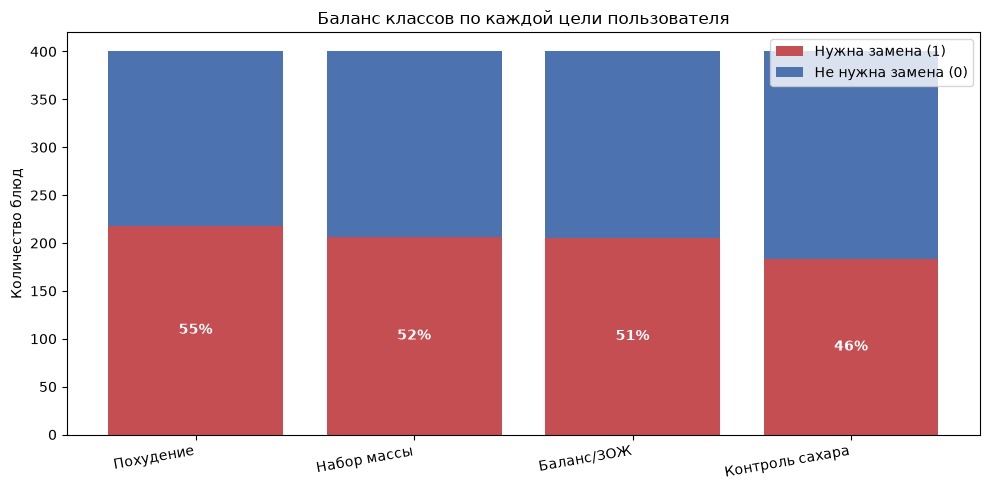

In [55]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

counts_need   = [df[t].sum() for t in targets]
counts_noneed = [len(df) - df[t].sum() for t in targets]
x = range(len(labels))

ax.bar(x, counts_need,   label='Нужна замена (1)',    color='#C44E52')
ax.bar(x, counts_noneed, label='Не нужна замена (0)', color='#4C72B0',
       bottom=counts_need)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, ha='right')
ax.set_ylabel('Количество блюд')
ax.set_title('Баланс классов по каждой цели пользователя')
ax.legend()

for i, (c1, c0) in enumerate(zip(counts_need, counts_noneed)):
    pct = round(c1 / len(df) * 100)
    ax.text(i, c1 / 2, f'{pct}%', ha='center', va='center',
            color='white', fontweight='bold')

plt.tight_layout()
plt.show()

**Вывод:** для каждой цели получилось достаточно сбалансированное распределение классов

## 5. Пример размеченных данных

In [56]:
cols_show = ['Food_Item', 'Calories (kcal)', 'Sugars (g)', 'Fat (g)', 'Protein (g)',
             'target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
df[cols_show].head(10)

,Food_Item,Calories (kcal),Sugars (g),Fat (g),Protein (g),target_weightloss,target_gainmass,target_balance,target_sugar
0,Борщ,50,2.0,2.0,2.8,0,1,1,0
1,Щи из свежей капусты,35,1.5,1.2,2.0,0,1,0,0
2,Щи из квашеной капусты,40,0.5,1.5,2.2,0,1,1,0
3,Рассольник,55,0.5,2.5,3.5,0,1,1,0
4,Солянка мясная,98,1.0,6.0,6.5,0,1,1,0
5,Уха,45,0.5,1.5,5.0,0,1,0,0
6,Окрошка на кефире,42,1.5,1.5,3.2,0,1,0,0
7,Гороховый суп,115,1.0,3.5,7.5,0,1,1,1
8,Куриный бульон,25,0.2,1.0,3.0,0,1,0,0
9,Грибной суп,38,1.0,1.2,2.5,0,1,0,0


## 6. Сохранение датасета с метками

In [57]:
df.to_csv('../data/russian_food_labeled.csv', index=False)
print('Файл сохранён: data/russian_food_labeled.csv')
print('Размер:', df.shape)
print('Целевые столбцы:', [c for c in df.columns if c.startswith('target_')])

Файл сохранён: data/russian_food_labeled.csv
Размер: (400, 14)
Целевые столбцы: ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']


## 7. Выводы по Этапу 3


1. Создано 4 целевые переменные (`target_weightloss`, `target_gainmass`, `target_balance`, `target_sugar`).
2. Пороги "высокое/низкое" определены через 70-й и 45-й перцентили **отдельно для каждого `Meal_Type`** — учитывает разницу в калорийности между завтраком, обедом и перекусом (см. вывод из EDA про широкий разброс у "Перекуса").
3. Распределение классов сбалансировано для всех целей.
4. Размеченный датасет сохранён в `data/russian_food_labeled.csv`.